In [38]:
import copy
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mp_colors
import matplotlib.cm as mp_cm

import lfes data, add rho column

In [39]:
lfes = pd.read_csv('../data/calculated/Joined_LFEs_w_phases.csv', usecols=['start', 'end', 'duration', 'subLST', 'subLat', 'R_ksm', 'x_ksm', 'y_ksm', 'z_ksm'])

lfes['rho'] = np.sqrt(lfes['x_ksm']**2 + lfes['y_ksm']**2)

#lfes

longest lfes by duration

In [40]:
n_longest = 10

longest_lfes = lfes.nlargest(n_longest, 'duration')

#longest_lfes

LFEs between 14-17 LST and >50 $R_s$

In [41]:
lfe_14_17_50 = lfes[(14<=lfes['subLST']) & (lfes['subLST']<=17) & (lfes['R_ksm']>=50)]
#lfe_14_17_50

LFEs between 05-06 LST and 80-90 $R_s$ 

In [42]:
lfe_5_6_80_90 = lfes[(5<=lfes['subLST']) & (lfes['subLST']<=6) & (lfes['R_ksm']>=80) & (lfes['R_ksm'] <= 90)]
#lfe_5_6_80_90

import ephemeris data

In [43]:
ephemeris = pd.read_csv('../data/calculated/20040101000000_20170915115700_ephemeris.csv', usecols=['x_ksm', 'y_ksm', 'z_ksm'])

ephemeris['rho'] = np.sqrt(ephemeris['x_ksm']**2 + ephemeris['y_ksm']**2)

In [44]:
# Choose bin limits
rho_min, rho_max = 0, 100
z_min, z_max = -50, 50

# Create bins (in saturn radii)
bin_size = 2
rho_bins = np.arange(rho_min, rho_max+2, bin_size)
z_bins = np.arange(z_min, z_max+2, bin_size)

## LFE data
# Bin the data
lfes['rho_bins'] = pd.cut(lfes['rho'], bins=rho_bins)
lfes['z_bins'] = pd.cut(lfes['z_ksm'], bins=z_bins)

# Create mapped data, ready to plot
lfe_counts = lfes.groupby(['z_bins', 'rho_bins']).size()
lfe_map = lfe_counts.to_numpy().reshape(len(z_bins)-1, len(rho_bins)-1)

## Repeat for ephemeris data
# Bin the data
ephemeris['rho_bins'] = pd.cut(ephemeris['rho'], bins=rho_bins)
ephemeris['z_bins'] = pd.cut(ephemeris['z_ksm'], bins=z_bins)

# Create mapped data, ready to plot
eph_counts = ephemeris.groupby(['z_bins', 'rho_bins']).size()
eph_map = eph_counts.to_numpy().reshape(len(z_bins)-1, len(rho_bins)-1)

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_1444\464367669.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lfe_counts = lfes.groupby(['z_bins', 'rho_bins']).size()
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_1444\464367669.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eph_counts = ephemeris.groupby(['z_bins', 'rho_bins']).size()


z-rho grid, 2 or 1 R_s bin. amount of lfe start in each bin

(-50.0, 50.0)

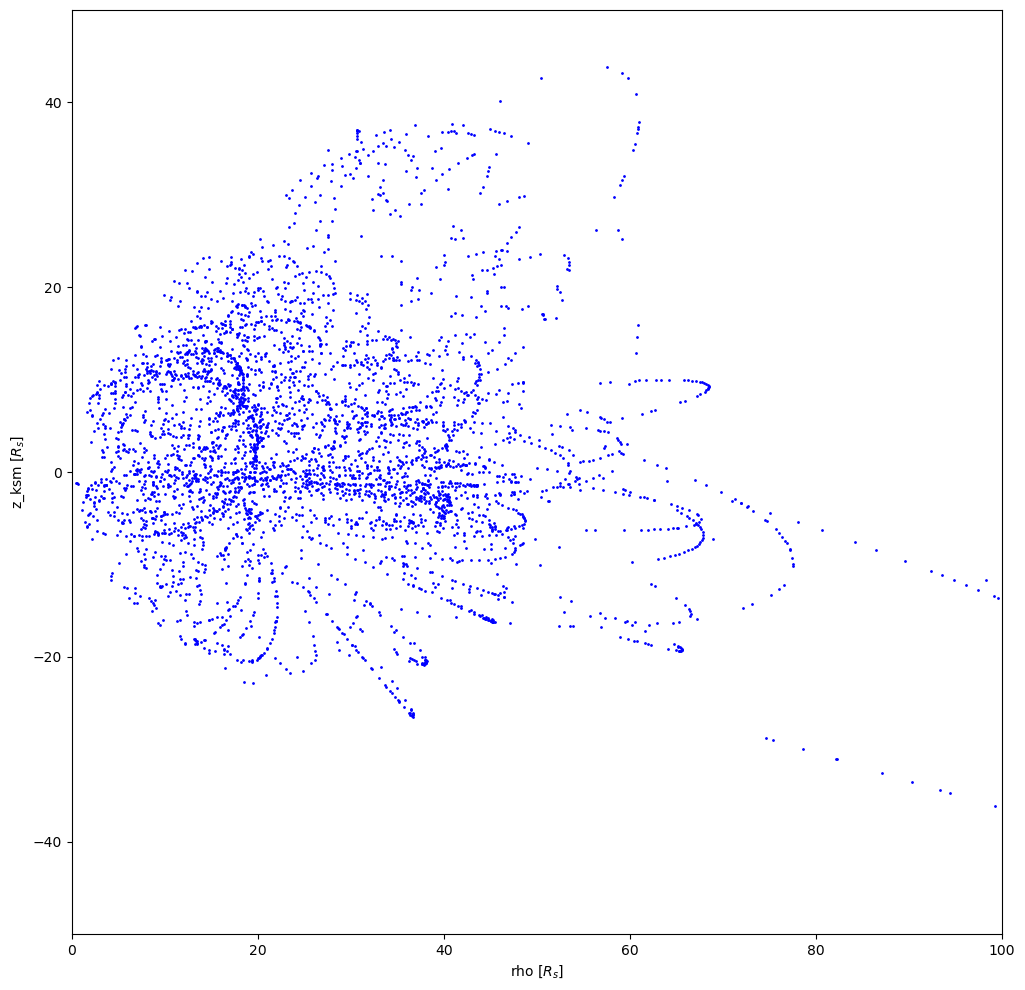

In [45]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot()

ax.plot(lfes['rho'], lfes['z_ksm'], '.', ms=2, c='blue')
ax.set_xlabel('rho $[R_{s}]$')
ax.set_ylabel('z_ksm $[R_{s}]$')

ax.set_xlim(rho_min, rho_max)
ax.set_ylim(z_min, z_max)

In [46]:
combined_map = np.copy(lfe_map).astype(float)

# Set values to nan where eph_map is 0
combined_map[eph_map == 0] = np.nan

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_1444\1060575194.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = copy.copy(mp_cm.get_cmap('inferno')) # copy the default cmap


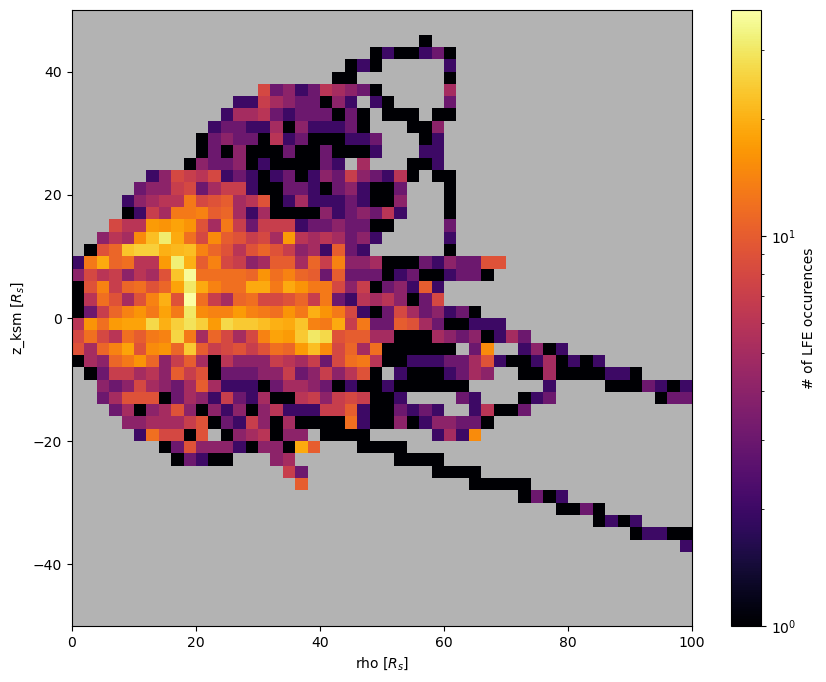

In [47]:
fig = plt.figure(figsize=(10,8), dpi=100)
ax = fig.add_subplot()

# Map of LFE counts
norm = mp_colors.LogNorm()

my_cmap = copy.copy(mp_cm.get_cmap('inferno')) # copy the default cmap
my_cmap.set_bad((0.7,0.7,0.7))#sets nans to grey (can make this white if I prefer "white")

map = ax.pcolormesh(rho_bins, z_bins, combined_map+1, cmap=my_cmap, norm=norm)
ax.set_xlabel('rho $[R_{s}]$')
ax.set_ylabel('z_ksm $[R_{s}]$')

ax.set_xlim(rho_min, rho_max)
ax.set_ylim(z_min, z_max)

# Colorbar
cbar = fig.colorbar(map, label='# of LFE occurences')

In [48]:
fig = plt.figure(figsize=(10,8), dpi=100)
ax = fig.add_subplot()

# Map of LFE counts
norm = mp_colors.LogNorm()
map = ax.pcolormesh(rho_bins, z_bins, lfe_map, cmap='inferno', norm=norm, facecolor='grey')
#ax.set_xlabel('$\rho [R_{s}]$')
#ax.set_ylabel('$z_{\rm ksm} [R_{s}]$')

#ax1.set_xlabel('$\Delta$T (minutes)',fontsize=20)

ax.set_xlabel('$\rho$ (RS)')
ax.set_ylabel('z')

ax.set_xlim(rho_min, rho_max)
ax.set_ylim(z_min, z_max)

# Colorbar
#cbar = fig.colorbar(map, label='# of LFE occurences', ticks=np.arange(start_map.min(), start_map.max()+1)[::2])

cbar = fig.colorbar(map, label='# of LFE occurrences')

Error in callback <function _draw_all_if_interactive at 0x0000027E7B031760> (for post_execute):


ValueError: 
$ho$ (RS)
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$ho$ (RS)
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1000x800 with 2 Axes>

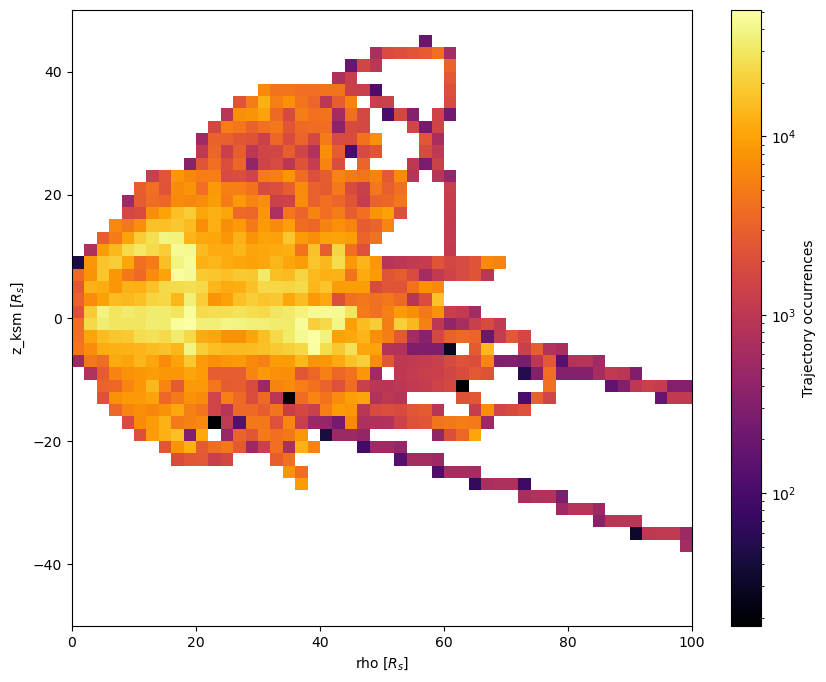

In [49]:
fig = plt.figure(figsize=(10,8), dpi=100)
ax = fig.add_subplot()

# Map of LFE counts
norm = mp_colors.LogNorm()
map = ax.pcolormesh(rho_bins, z_bins, eph_map, cmap='inferno', norm=norm, facecolor='grey')
ax.set_xlabel('rho $[R_{s}]$')
ax.set_ylabel('z_ksm $[R_{s}]$')


ax.set_xlim(rho_min, rho_max)
ax.set_ylim(z_min, z_max)

# Colorbar
#cbar = fig.colorbar(map, label='# of LFE occurences', ticks=np.arange(start_map.min(), start_map.max()+1)[::2])

cbar = fig.colorbar(map, label='Trajectory occurrences')

1) Spacecraft was never there (nan)
2) Spacecraft was there but no LFEs (0)
3) Spacecraft was there and LFEs (colorbar)